In [14]:
import pandas as pd
df = pd.read_csv(r'C:\Users\SIDHARTH\Downloads\Main project\books 4.csv')
df.head(5)

,asin,reviewText,overall,category,summary
0,0312950489,Great author and great book.,5.0,Books_5,Five Stars
1,0312950489,"Re-read this, as I wait, ever so patiently.......",5.0,Books_5,Waiting for Bosch the video series.....
2,0312950489,Always enjoy a Connelly book. Great read.,5.0,Books_5,Five Stars
3,0312938640,"As a middle aged, third generation Angelino, w...",5.0,Books_5,I am hooked
4,0312938640,You just can't beat Michael Connelly.,4.0,Books_5,Four Stars


In [15]:
df.tail(5)

,asin,reviewText,overall,category,summary
3980476,0615441866,Excellent read. Enjoyed it,5.0,Books_5,Five Stars
3980477,0615441866,Exciting! Got confused when I started this boo...,5.0,Books_5,Hard to put down
3980478,0615426263,Did not even finish. I think this book is tot...,1.0,Books_5,not worth my time
3980479,0615426263,I have always been a fan of Michael Baisden's ...,4.0,Books_5,Michael Baisden
3980480,0615426263,I am not surprised by what I read in this book...,5.0,Books_5,Let the truth be told


In [16]:
df.shape

(3980481, 5)

In [17]:
df.sample(5)

,asin,reviewText,overall,category,summary
2124459,0399255141,"No matter how you tell it, the tale of the thr...",5.0,Books_5,Another Great Retelling of the Three Little Pigs
1116790,0373775571,"This book was moving, emotional and lovely. Ha...",5.0,Books_5,The Best Kristan Higgins yet!
2049450,0399159010,"Rest up before reading, because this book is e...",5.0,Books_5,in a good way. Jenny Lawson writes with so muc...
3761556,0553589636,While I have always enjoyed science fiction te...,5.0,Books_5,5 Stars
1734162,0393063798,This book is considered the go-to for second-w...,5.0,Books_5,Fantastic sociological/feminist examination.


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3980481 entries, 0 to 3980480
Data columns (total 5 columns):
 #   Column      Dtype  
---  ------      -----  
 0   asin        object 
 1   reviewText  object 
 2   overall     float64
 3   category    object 
 4   summary     object 
dtypes: float64(1), object(4)
memory usage: 151.8+ MB


In [19]:
df.columns

Index(['asin', 'reviewText', 'overall', 'category', 'summary'], dtype='object')

Rating Distribution

C:\Users\SIDHARTH\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


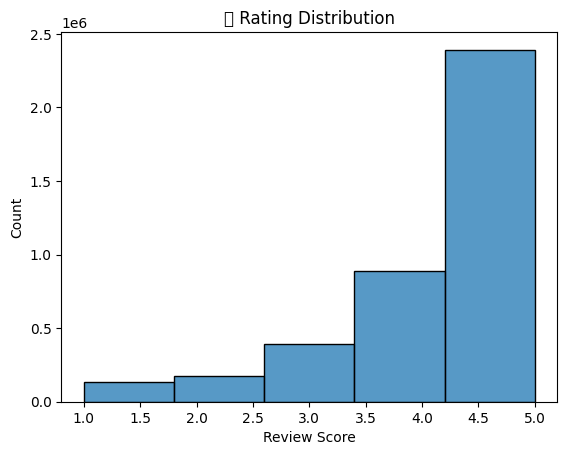

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['overall'], bins=5)
plt.title("📈 Rating Distribution")
plt.xlabel("Review Score")
plt.ylabel("Count")
plt.show()


Review Length vs. Rating

C:\Users\SIDHARTH\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128221 (\N{MEMO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


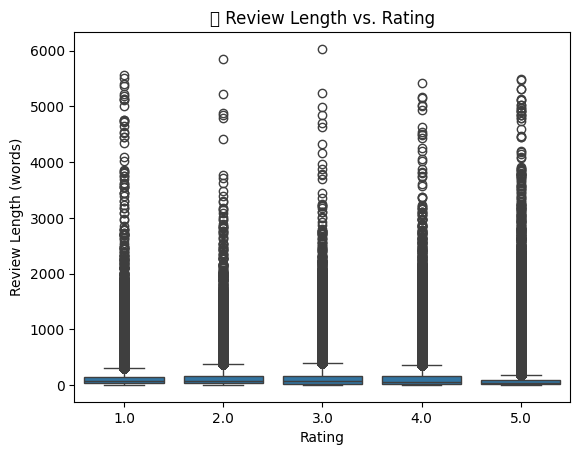

In [21]:
df['length'] = df['reviewText'].fillna('').apply(lambda x: len(x.split()))

sns.boxplot(data=df, x='overall', y='length')
plt.title("📝 Review Length vs. Rating")
plt.xlabel("Rating")
plt.ylabel("Review Length (words)")
plt.show()


Category-Level Rating Trends

C:\Users\SIDHARTH\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128218 (\N{BOOKS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


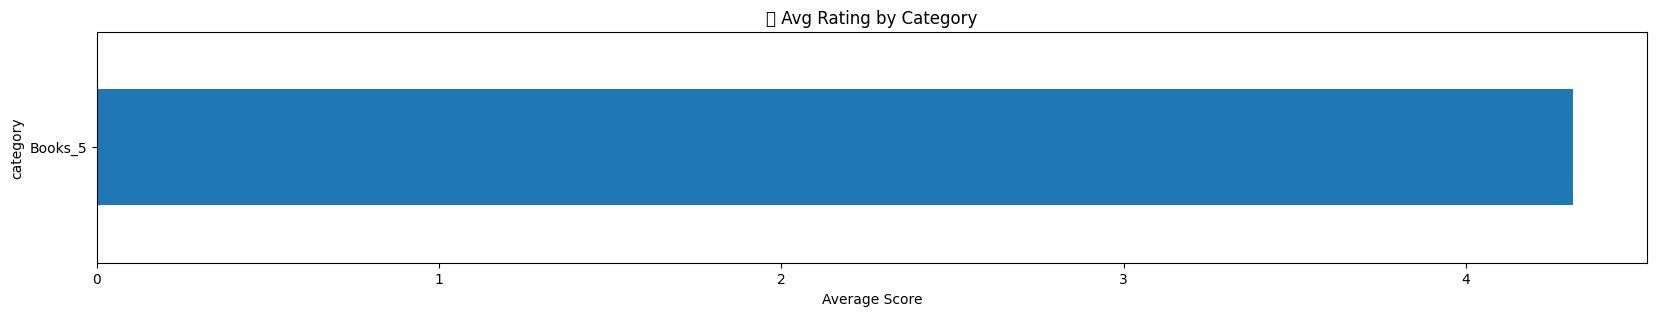

In [26]:
category_avg = df.groupby('category')['overall'].mean().sort_values()
category_avg.plot(kind='barh', figsize=(20, 3), title="📚 Avg Rating by Category")
plt.xlabel("Average Score")
plt.show()



In [27]:
df.drop(columns=['asin',  'category', 'summary'],inplace=True)

In [28]:
df.columns

Index(['reviewText', 'overall', 'length'], dtype='object')

In [29]:
df.isnull().sum()

reviewText    145
overall         0
length          0
dtype: int64

In [30]:
df.dropna(inplace=True)

In [31]:
df.isnull().sum()

reviewText    0
overall       0
length        0
dtype: int64

In [32]:
df.rename(columns={'reviewText':'review','overall':'rating'},inplace=True)

In [33]:
df.head(5)

,review,rating,length
0,Great author and great book.,5.0,5
1,"Re-read this, as I wait, ever so patiently.......",5.0,8
2,Always enjoy a Connelly book. Great read.,5.0,7
3,"As a middle aged, third generation Angelino, w...",5.0,198
4,You just can't beat Michael Connelly.,4.0,6


In [34]:
print(df.duplicated().sum())

235557


In [35]:
df.drop_duplicates(subset=['review','rating'],inplace=True)

In [36]:
print(df.duplicated().sum())

0


In [37]:
import re

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^\w\s]", "", text)
    text = re.sub(r"\d+", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df.loc[:, "review"] = df["review"].apply(clean_text)

In [38]:
df['rating']=df['rating'].astype(int)

In [39]:
df['rating'].value_counts()

rating
5    2203571
4     857456
3     379404
2     170563
1     133785
Name: count, dtype: int64

In [40]:
df.shape

(3744779, 3)

In [41]:
df.sample(5)

,review,rating,length
1380175,mother earth father sky is the first book in a...,5,261
3486434,obviously you are considering starting the per...,5,72
3400753,i hope karen english isnt burning out with thi...,2,71
256522,if youve read and enjoyed martinez other books...,4,81
1275564,all of brysons books are fun and easy to read ...,4,90


In [42]:
df.to_csv('D-BOOKS - 4 DL.csv',index=False)